# Entrenamiento y evaluación de modelos — Pago a tiempo
Baseline Random Forest → XGBoost (Grid Search) → LightGBM → CatBoost → Stacking.

**Nota:** en la versión anterior todos los modelos daban métricas de 1.0. Antes de entrenar, se agregó un chequeo de fuga de datos (duplicados train/test y correlación de cada variable con el target) para detectar la causa real, en vez de asumir cuál es.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    KFold, StratifiedKFold, TimeSeriesSplit, cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from ft_engineering import preprocesar_datos

## Cargar y preprocesar los datos

In [2]:
datos = preprocesar_datos()

X_train = datos["X_train"]
X_test = datos["X_test"]
y_train = datos["y_train"]
y_test = datos["y_test"]
orden_train = datos["orden_train"]
feature_names = datos["feature_names"]


DATASET LIMPIO
  tipo_credito  capital_prestado  plazo_meses  edad_cliente   tipo_laboral  \
0            C         3692160.0           10            42  Independiente   
1            A          840000.0            6            60       Empleado   
2            D         5974028.4           10            36  Independiente   
3            A         1671240.0            6            48       Empleado   
4            D         2781636.0           11            44       Empleado   

   salario_cliente  total_otros_prestamos  cuota_pactada  puntaje_datacredito  \
0          8000000                2500000         341296                  695   
1          3000000                2000000         124876                  789   
2          4036000                 829000         529554                  740   
3          1524547                 498000         252420                  837   
4          5000000                4000000         217037                  771   

   cant_creditosvigentes  ..

## Diagnóstico de fuga de datos
Que **todos** los modelos den 1.0 en las métricas casi siempre significa que alguna variable ya contiene información del resultado (o que hay filas duplicadas entre train y test), no que el modelo sea perfecto. Se revisan ambas cosas antes de seguir.

In [3]:
print("Verificación de posible fuga de datos")
print("=" * 70)

df_train_feat = pd.DataFrame(X_train, columns=feature_names)
df_test_feat = pd.DataFrame(X_test, columns=feature_names)

# 1) Filas idénticas entre X_train y X_test
duplicadas = df_train_feat.merge(df_test_feat, how="inner")
print(f"Filas idénticas entre X_train y X_test: {len(duplicadas)}")

# 2) Correlación de cada variable con el target
correlaciones = df_train_feat.corrwith(y_train.astype(float)).abs().sort_values(ascending=False)
print("\nTop 15 variables más correlacionadas con Pago_atiempo:")
print(correlaciones.head(15))

sospechosas = correlaciones[correlaciones > 0.9]
if len(sospechosas) > 0:
    print("\n⚠️  Variables con correlación > 0.9 con el target (revisar si son fuga de datos):")
    print(sospechosas)
else:
    print("\nNinguna variable individual supera 0.9 de correlación con el target.")

Verificación de posible fuga de datos
Filas idénticas entre X_train y X_test: 0

Top 15 variables más correlacionadas con Pago_atiempo:
num__puntaje_datacredito              0.112796
cat__tipo_credito_B                   0.083407
num__plazo_meses                      0.065617
num__saldo_mora                       0.058929
num__edad_cliente                     0.049959
num__capital_prestado                 0.044843
num__fin_de_semana                    0.042054
num__promedio_ingresos_datacredito    0.039358
cat__tipo_laboral_Independiente       0.036488
cat__tipo_laboral_Empleado            0.036488
cat__tendencia_ingresos_Creciente     0.033342
num__dia_semana                       0.033202
num__creditos_sectorReal              0.030460
num__creditos_sectorCooperativo       0.020993
cat__tendencia_ingresos_Estable       0.020688
dtype: float64

Ninguna variable individual supera 0.9 de correlación con el target.


**Si aparece alguna variable sospechosa arriba** (por ejemplo, algo derivado del propio pago, como `saldo_mora` si por definición marca si hubo o no atraso), hay que sacarla de `X` en `ft_engineering.py` antes de seguir — de lo contrario los modelos de abajo van a seguir dando 1.0 sin importar cuál se use.

## Funciones de evaluación

In [4]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test, feature_names):

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print("=" * 70)
    print(nombre)
    print("=" * 70)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.tight_layout()
    plt.show()

    if hasattr(modelo, "feature_importances_"):
        importancias = pd.Series(modelo.feature_importances_, index=feature_names)
        top10 = importancias.sort_values(ascending=True).tail(10)

        plt.figure(figsize=(8, 6))
        top10.plot(kind="barh")
        plt.title(f"Top 10 variables más importantes - {nombre}")
        plt.xlabel("Importancia")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{nombre} no expone feature_importances_, se omite el gráfico.")

    return {
        "modelo": modelo, "y_pred": y_pred, "y_proba": y_proba,
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": roc,
    }

In [5]:
def evaluar_cv(nombre, modelo, X_train, y_train, orden_train):

    print(f"Validación cruzada - {nombre}")

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    scores_kfold = cross_val_score(modelo, X_train, y_train, cv=kfold, scoring="f1")
    print(f"KFold           F1: {scores_kfold.mean():.4f} +/- {scores_kfold.std():.4f}")

    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores_skfold = cross_val_score(modelo, X_train, y_train, cv=skfold, scoring="f1")
    print(f"StratifiedKFold F1: {scores_skfold.mean():.4f} +/- {scores_skfold.std():.4f}")

    # TimeSeriesSplit necesita las filas ordenadas en el tiempo
    orden = np.argsort(orden_train.values)
    X_train_ordenado = X_train[orden]
    y_train_ordenado = y_train.iloc[orden].reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=5)
    scores_tscv = cross_val_score(modelo, X_train_ordenado, y_train_ordenado, cv=tscv, scoring="f1")
    print(f"TimeSeriesSplit F1: {scores_tscv.mean():.4f} +/- {scores_tscv.std():.4f}")

## Random Forest (baseline)

RandomForest
Accuracy : 0.9542
Precision: 0.9541
Recall   : 1.0000
F1 Score : 0.9765
ROC-AUC  : 0.6562


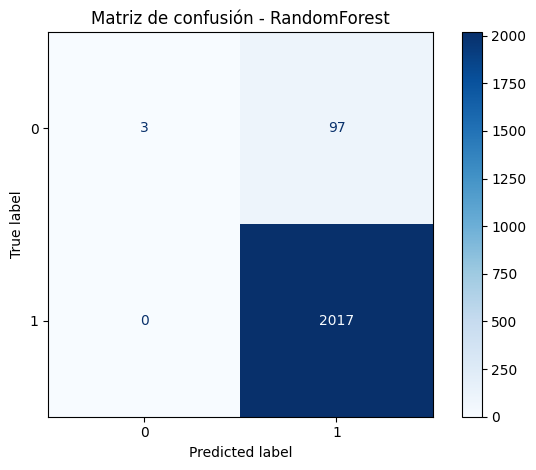

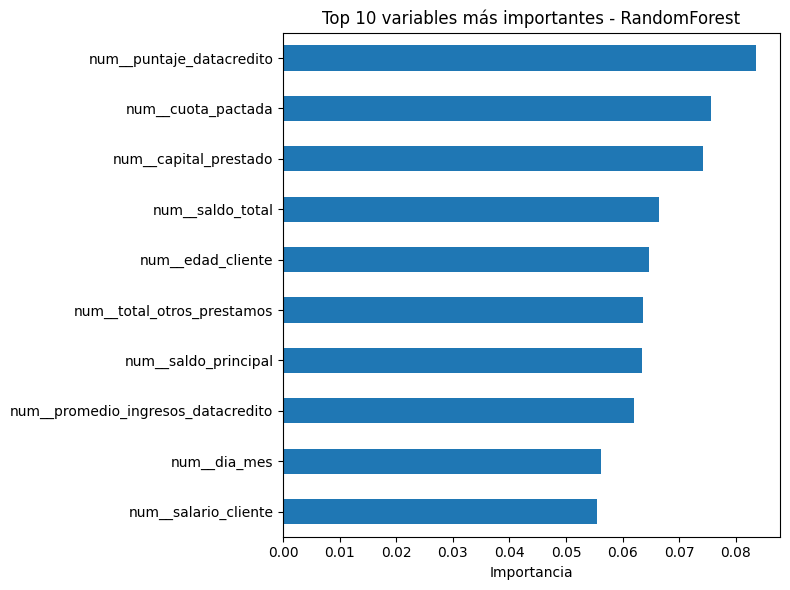

Validación cruzada - RandomForest
KFold           F1: 0.9758 +/- 0.0016
StratifiedKFold F1: 0.9760 +/- 0.0006
TimeSeriesSplit F1: 0.9769 +/- 0.0043


In [6]:
resultados = {}

rf = RandomForestClassifier(random_state=42)
resultados["RandomForest"] = evaluar_modelo(
    "RandomForest", rf, X_train, y_train, X_test, y_test, feature_names
)
evaluar_cv("RandomForest", rf, X_train, y_train, orden_train)

## XGBoost (con Grid Search)

Mejores parámetros XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
XGBoost
Accuracy : 0.9542
Precision: 0.9550
Recall   : 0.9990
F1 Score : 0.9765
ROC-AUC  : 0.7018


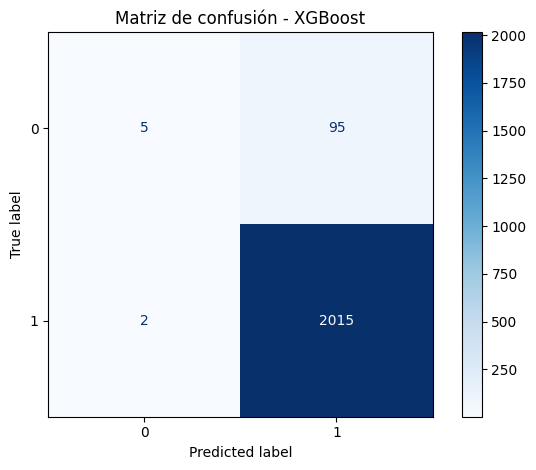

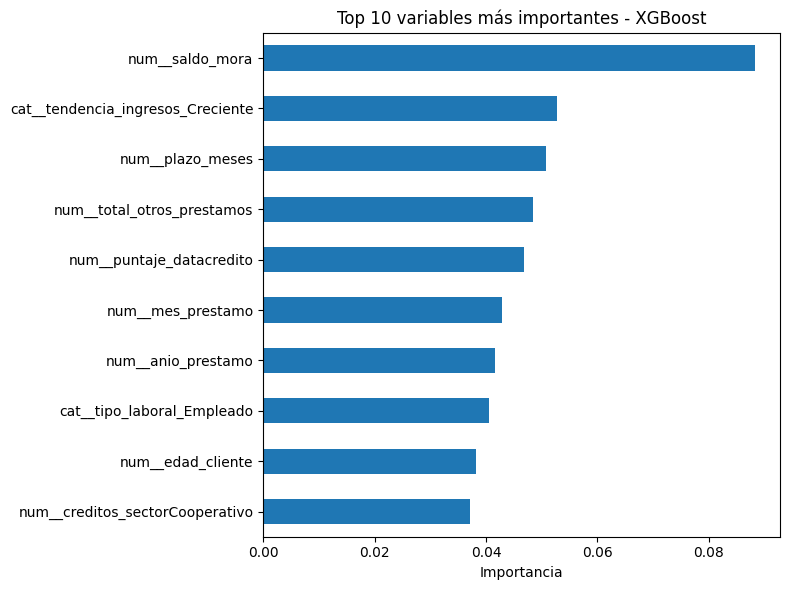

Validación cruzada - XGBoost
KFold           F1: 0.9761 +/- 0.0016
StratifiedKFold F1: 0.9761 +/- 0.0004
TimeSeriesSplit F1: 0.9760 +/- 0.0036


In [7]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
)
grid_xgb.fit(X_train, y_train)
print(f"Mejores parámetros XGBoost: {grid_xgb.best_params_}")

xgb_best = grid_xgb.best_estimator_
resultados["XGBoost"] = evaluar_modelo(
    "XGBoost", xgb_best, X_train, y_train, X_test, y_test, feature_names
)
evaluar_cv("XGBoost", xgb_best, X_train, y_train, orden_train)

## LightGBM

[LightGBM] [Info] Number of positive: 8068, number of negative: 399
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001762 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2277
[LightGBM] [Info] Number of data points in the train set: 8467, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.952876 -> initscore=3.006699
[LightGBM] [Info] Start training from score 3.006699


c:\Users\isaac\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\isaac\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\isaac\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\isaac\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, c

LightGBM
Accuracy : 0.9523
Precision: 0.9549
Recall   : 0.9970
F1 Score : 0.9755
ROC-AUC  : 0.6814


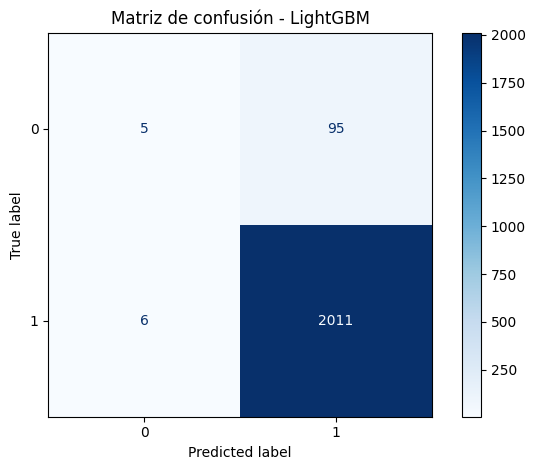

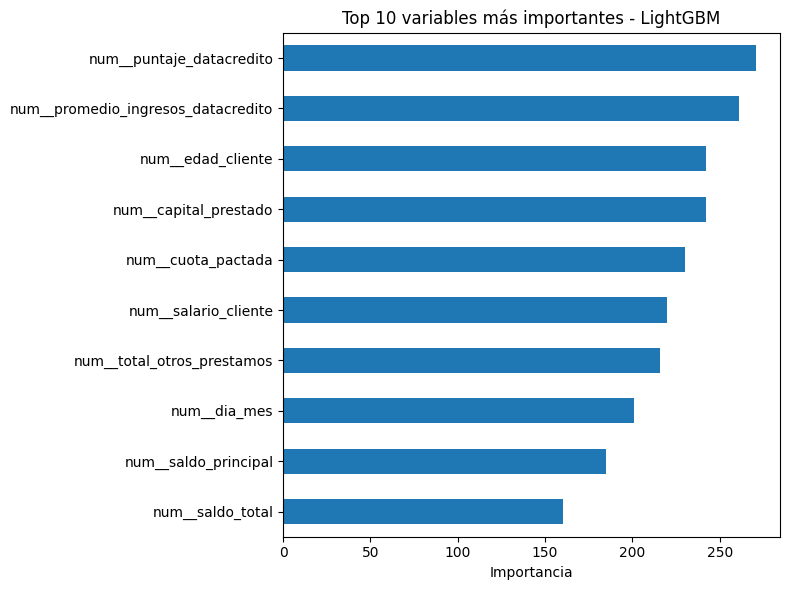

Validación cruzada - LightGBM
[LightGBM] [Info] Number of positive: 6456, number of negative: 317
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2267
[LightGBM] [Info] Number of data points in the train set: 6773, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.953197 -> initscore=3.013863
[LightGBM] [Info] Start training from score 3.013863
[LightGBM] [Info] Number of positive: 6451, number of negative: 322
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2269
[LightGBM] [Info] Number of data points in the train set: 6773, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.952458 -> initscore=2.997439
[LightGBM] [Info] Start training from score 2.9

In [8]:
lgbm = LGBMClassifier(random_state=42)
resultados["LightGBM"] = evaluar_modelo(
    "LightGBM", lgbm, X_train, y_train, X_test, y_test, feature_names
)
evaluar_cv("LightGBM", lgbm, X_train, y_train, orden_train)

## CatBoost

CatBoost
Accuracy : 0.9537
Precision: 0.9550
Recall   : 0.9985
F1 Score : 0.9762
ROC-AUC  : 0.7063


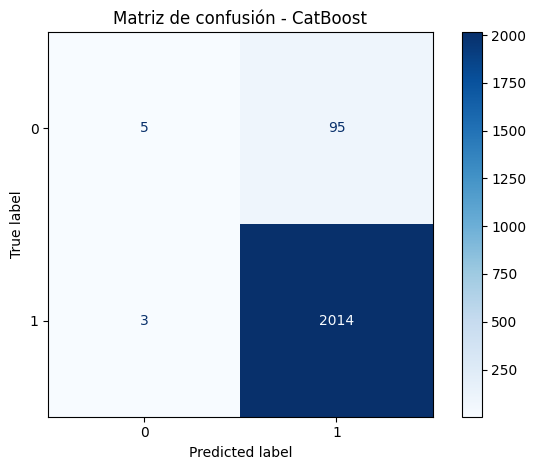

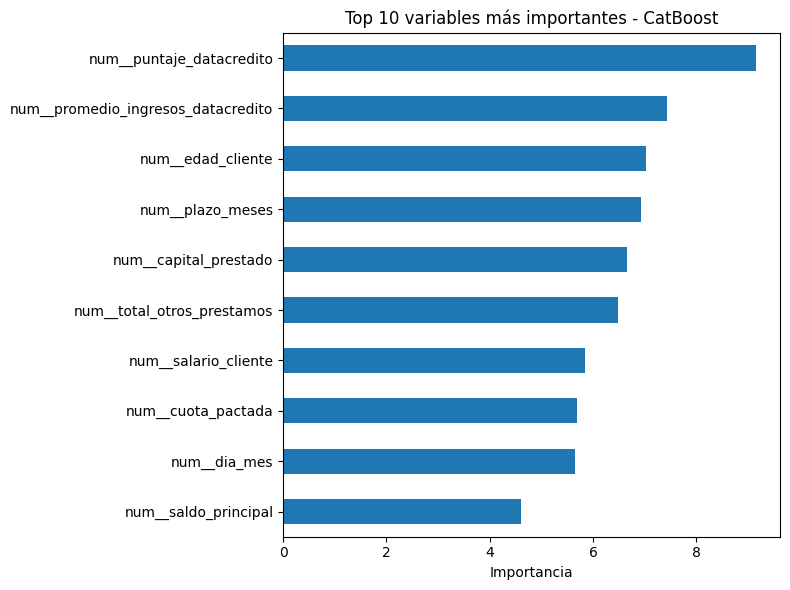

Validación cruzada - CatBoost
KFold           F1: 0.9759 +/- 0.0015
StratifiedKFold F1: 0.9759 +/- 0.0003
TimeSeriesSplit F1: 0.9767 +/- 0.0041


In [9]:
cat = CatBoostClassifier(random_state=42, verbose=0)
resultados["CatBoost"] = evaluar_modelo(
    "CatBoost", cat, X_train, y_train, X_test, y_test, feature_names
)
evaluar_cv("CatBoost", cat, X_train, y_train, orden_train)

## Stacking

[LightGBM] [Info] Number of positive: 8068, number of negative: 399
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001976 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2277
[LightGBM] [Info] Number of data points in the train set: 8467, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.952876 -> initscore=3.006699
[LightGBM] [Info] Start training from score 3.006699
[LightGBM] [Info] Number of positive: 6454, number of negative: 319
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2270
[LightGBM] [Info] Number of data points in the train set: 6773, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.952901 -> initscore=3.007264
[LightGBM] [Info] Start training from score 3.007264
[LightGBM] [Info] Number

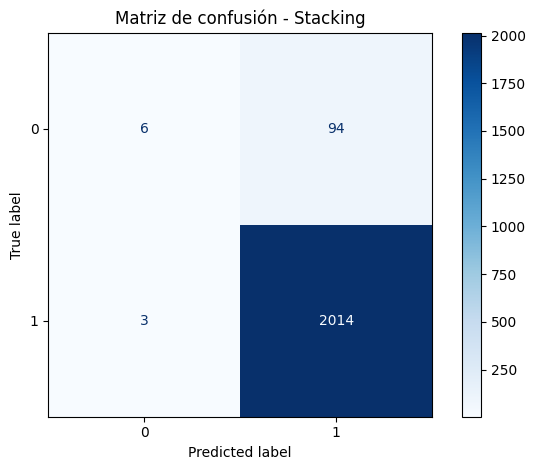

Stacking no expone feature_importances_, se omite el gráfico.
Validación cruzada - Stacking
[LightGBM] [Info] Number of positive: 6456, number of negative: 317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001445 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2267
[LightGBM] [Info] Number of data points in the train set: 6773, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.953197 -> initscore=3.013863
[LightGBM] [Info] Start training from score 3.013863
[LightGBM] [Info] Number of positive: 5165, number of negative: 253
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2257
[LightGBM] [Info] Number of data points in the train set: 5418, number of used features: 29


In [10]:
stacking = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(random_state=42)),
        ("xgb", XGBClassifier(**grid_xgb.best_params_, random_state=42, eval_metric="logloss")),
        ("lgbm", LGBMClassifier(random_state=42)),
        ("catboost", CatBoostClassifier(random_state=42, verbose=0)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
)

resultados["Stacking"] = evaluar_modelo(
    "Stacking", stacking, X_train, y_train, X_test, y_test, feature_names
)
evaluar_cv("Stacking", stacking, X_train, y_train, orden_train)

## Comparación de modelos

In [11]:
comparacion = pd.DataFrame({
    nombre: {k: v for k, v in r.items() if k in ("accuracy", "precision", "recall", "f1", "roc_auc")}
    for nombre, r in resultados.items()
}).T

comparacion

,accuracy,precision,recall,f1,roc_auc
RandomForest,0.954180,0.954115,1.000000,0.976519,0.656173
XGBoost,0.954180,0.954976,0.999008,0.976496,0.701755
LightGBM,0.952291,0.954891,0.997025,0.975503,0.681413
CatBoost,0.953708,0.954955,0.998513,0.976248,0.706277
Stacking,0.954180,0.955408,0.998513,0.976485,0.695240


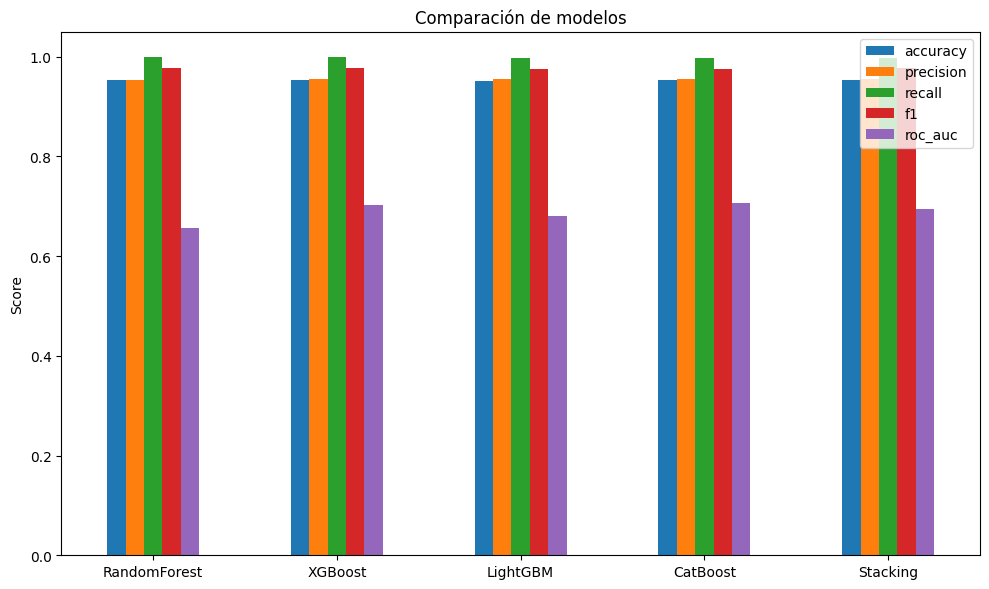

In [12]:
comparacion.plot(kind="bar", figsize=(10, 6))
plt.title("Comparación de modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Curvas ROC y Precision-Recall

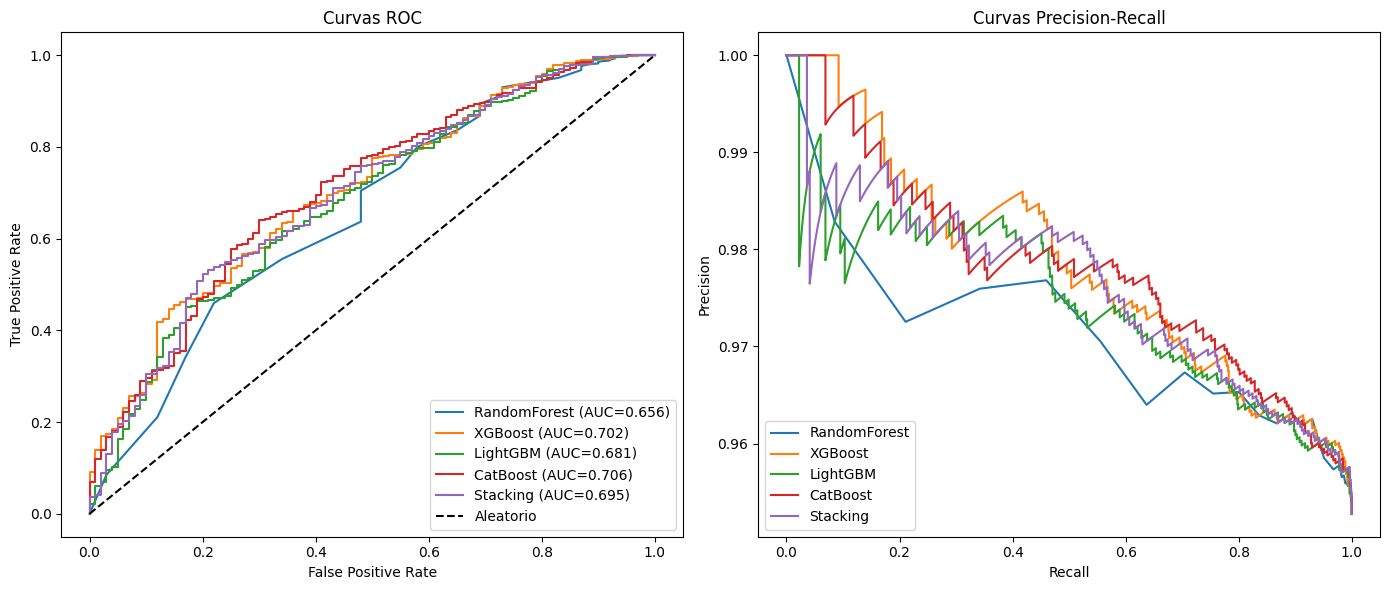

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for nombre, r in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{nombre} (AUC={r['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Aleatorio")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curvas ROC")
axes[0].legend(loc="lower right")

for nombre, r in resultados.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, r["y_proba"])
    axes[1].plot(rec_curve, prec_curve, label=nombre)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curvas Precision-Recall")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## Conclusión

In [14]:
mejor = comparacion["f1"].idxmax()
print(f"Mejor modelo según F1: {mejor}")
print(comparacion.loc[mejor])

Mejor modelo según F1: RandomForest
accuracy     0.954180
precision    0.954115
recall       1.000000
f1           0.976519
roc_auc      0.656173
Name: RandomForest, dtype: float64


---
# Aprendizaje No Supervisado — Segmentación de clientes
K-Means (codo + silhouette) → DBSCAN (outliers) → PCA / t-SNE (visualización) → tasa de incumplimiento y perfiles por segmento.

Se reutiliza `X_train` ya imputado y codificado por `preprocesar_datos()`, pero para K-Means/PCA/DBSCAN hace falta escalarlo aparte (son sensibles a la escala, a diferencia de los modelos de árboles usados arriba). `puntaje` sigue fuera por ser fuga de datos: incluirla aquí solo agruparía a los clientes por el propio resultado, no por sus características reales.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

scaler_cluster = StandardScaler()
X_train_scaled = scaler_cluster.fit_transform(X_train)

## Método del codo y coeficiente de Silhouette

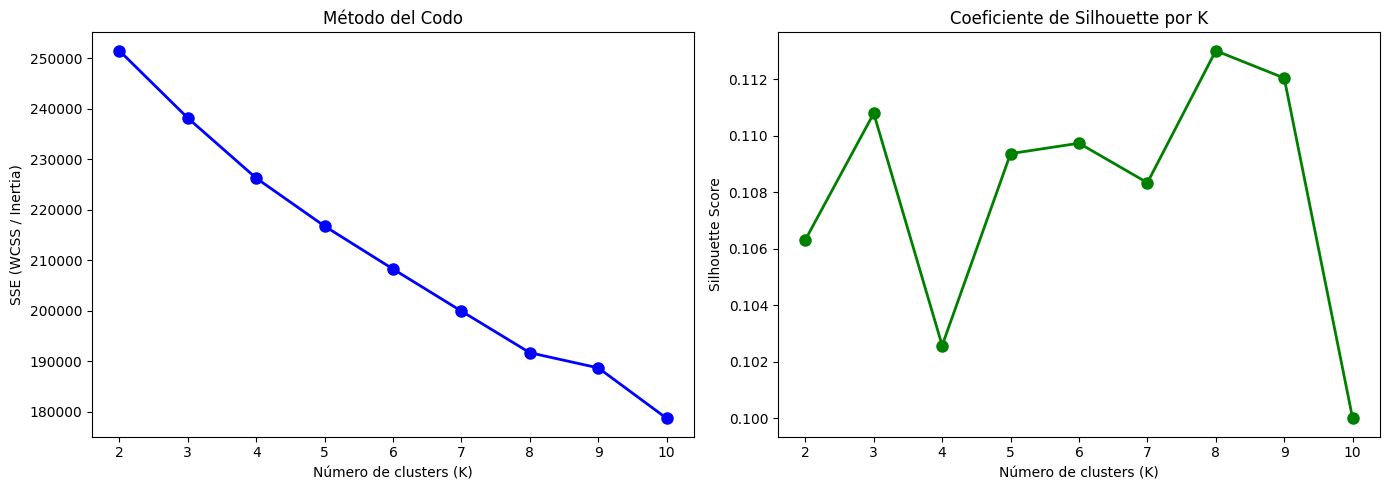

In [16]:
k_range = range(2, 11)
sse_list = []
silhouette_list = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    sse_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_train_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, sse_list, "bo-", linewidth=2, markersize=8)
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("SSE (WCSS / Inertia)")
axes[0].set_title("Método del Codo")
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_list, "go-", linewidth=2, markersize=8)
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Coeficiente de Silhouette por K")
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

## K-Means: elegir K entre 3, 4 y 5 por Silhouette

In [17]:
k_values = [3, 4, 5]
kmeans_models = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    kmeans_models[k] = km
    sil = silhouette_score(X_train_scaled, km.labels_)
    print(f"K={k}: Silhouette={sil:.4f}, tamaños: {np.bincount(km.labels_)}")

k_final = max(k_values, key=lambda k: silhouette_score(X_train_scaled, kmeans_models[k].labels_))
print(f"\nK óptimo por Silhouette: {k_final}")

cluster_kmeans = kmeans_models[k_final].labels_

K=3: Silhouette=0.1108, tamaños: [2797 1366 4304]
K=4: Silhouette=0.1026, tamaños: [ 735 3921 1317 2494]
K=5: Silhouette=0.1094, tamaños: [ 505 1805 1217 1770 3170]

K óptimo por Silhouette: 3


## Centroides en escala original (interpretables)

In [18]:
centroids_original = scaler_cluster.inverse_transform(kmeans_models[k_final].cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=feature_names)
centroids_df.insert(0, "Cluster", range(k_final))
centroids_df

,Cluster,num__capital_prestado,num__plazo_meses,num__edad_cliente,num__salario_cliente,num__total_otros_prestamos,num__cuota_pactada,num__puntaje_datacredito,num__cant_creditosvigentes,num__saldo_mora,...,cat__tipo_credito_A,cat__tipo_credito_B,cat__tipo_credito_C,cat__tipo_credito_D,cat__tipo_credito_E,cat__tipo_laboral_Empleado,cat__tipo_laboral_Independiente,cat__tendencia_ingresos_Creciente,cat__tendencia_ingresos_Decreciente,cat__tendencia_ingresos_Estable
0,0,2.573390e+06,8.919199,45.310332,1.272437e+07,2.612331e+06,292200.647122,794.672149,6.230604,4.706829,...,0.662138,2.168404e-18,1.355253e-19,0.328566,0.009296,0.003575,9.964247e-01,0.388988,0.086879,0.524133
1,1,2.285603e+06,12.450952,41.978038,3.513901e+06,1.158162e+06,200154.659590,784.829429,5.529283,18.477306,...,0.818448,7.320644e-04,7.320644e-04,0.164714,0.015373,0.705710,2.942899e-01,0.373353,0.129575,0.497072
2,2,2.297810e+06,11.042519,41.845725,7.708313e+06,1.313065e+06,217154.603160,792.647537,5.656366,6.190056,...,0.747909,3.252788e-03,-5.149960e-19,0.236989,0.011849,1.000000,9.436896e-16,0.609433,0.139638,0.250929


## DBSCAN: detección de outliers

In [19]:
db = DBSCAN(eps=0.5, min_samples=5)
db.fit(X_train_scaled)
labels_db = db.labels_

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

print("Resultados DBSCAN")
print("=" * 50)
print(f"Clusters encontrados: {n_clusters_db}")
print(f"Outliers (ruido): {n_noise} ({n_noise / len(labels_db) * 100:.1f}%)")

outliers_mask = labels_db == -1
if outliers_mask.sum() > 0:
    tasa_outliers = 1 - y_train[outliers_mask].mean()
    tasa_resto = 1 - y_train[~outliers_mask].mean()
    print(f"\nTasa de NO pago a tiempo - Outliers: {tasa_outliers * 100:.1f}%")
    print(f"Tasa de NO pago a tiempo - Resto    : {tasa_resto * 100:.1f}%")
else:
    print("No se detectaron outliers con eps=0.5, min_samples=5.")

Resultados DBSCAN
Clusters encontrados: 0
Outliers (ruido): 8467 (100.0%)

Tasa de NO pago a tiempo - Outliers: 4.7%
Tasa de NO pago a tiempo - Resto    : nan%


## PCA: varianza explicada y proyección 2D

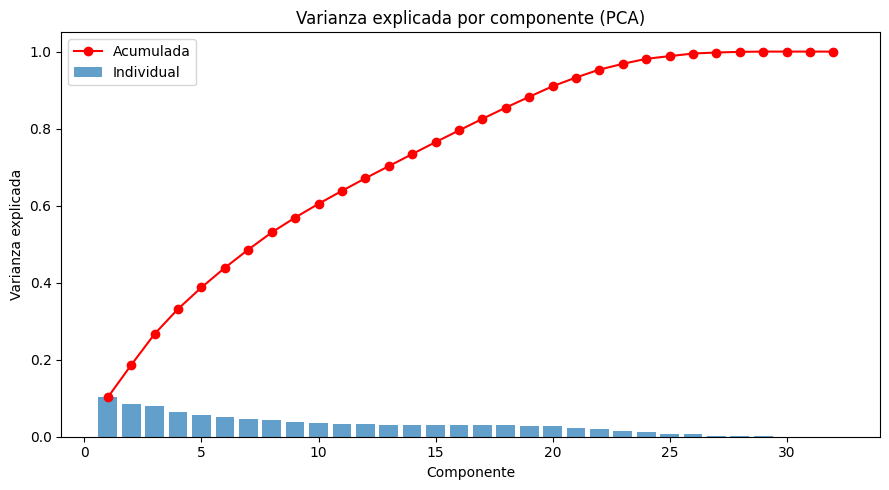

Componentes para 80% varianza: 17
Componentes para 90% varianza: 20


In [20]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

var_exp = pca_full.explained_variance_ratio_
var_exp_cum = np.cumsum(var_exp)

n_80 = np.searchsorted(var_exp_cum, 0.80) + 1
n_90 = np.searchsorted(var_exp_cum, 0.90) + 1

plt.figure(figsize=(9, 5))
plt.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.7, label="Individual")
plt.plot(range(1, len(var_exp) + 1), var_exp_cum, "ro-", label="Acumulada")
plt.xlabel("Componente")
plt.ylabel("Varianza explicada")
plt.title("Varianza explicada por componente (PCA)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Componentes para 80% varianza: {n_80}")
print(f"Componentes para 90% varianza: {n_90}")

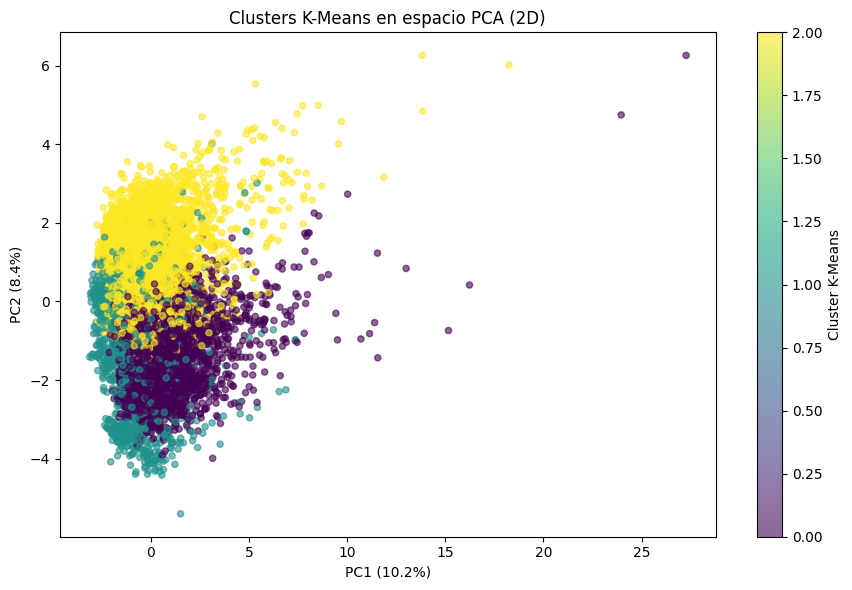

In [21]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_kmeans, cmap="viridis", alpha=0.6, s=20)
plt.colorbar(scatter, label="Cluster K-Means")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Clusters K-Means en espacio PCA (2D)")
plt.tight_layout()
plt.show()

## t-SNE: visualización no lineal
Puede tardar 1-2 min según el tamaño del dataset.

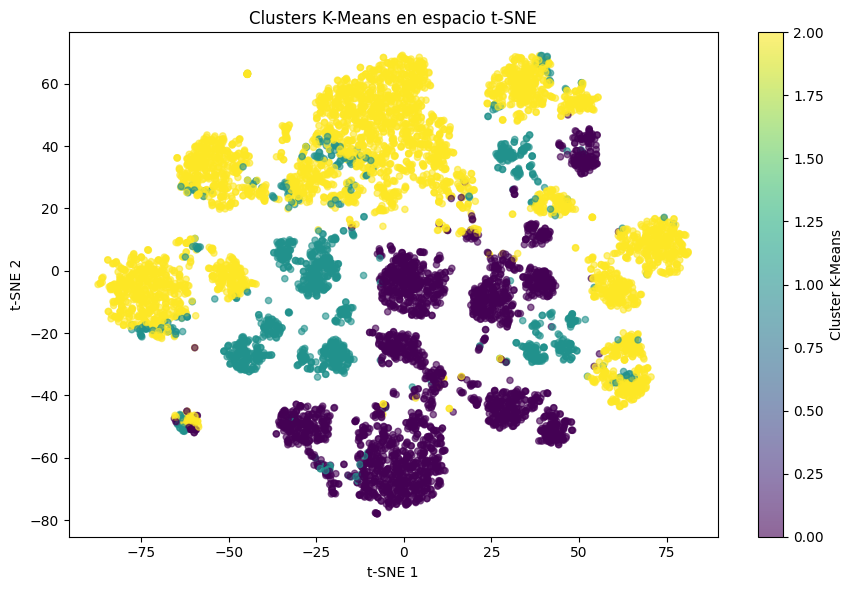

In [22]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_kmeans, cmap="viridis", alpha=0.6, s=20)
plt.colorbar(scatter, label="Cluster K-Means")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Clusters K-Means en espacio t-SNE")
plt.tight_layout()
plt.show()

## Tasa de incumplimiento por segmento

Tasa de incumplimiento por cluster (K-Means)
   cluster  count  Tasa_incumplimiento_%
0        0   2797                    5.4
1        1   1366                    5.3
2        2   4304                    4.1


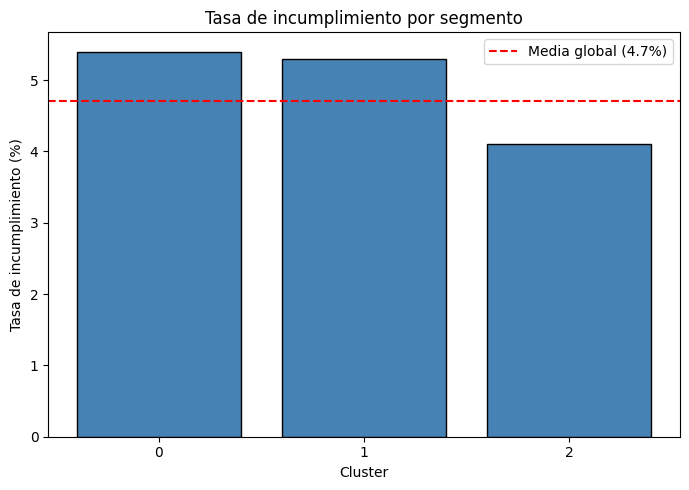

In [23]:
df_seg = pd.DataFrame({"cluster": cluster_kmeans, "Pago_atiempo": y_train.values})

resumen_cluster = df_seg.groupby("cluster")["Pago_atiempo"].agg(["mean", "count"])
resumen_cluster["Tasa_incumplimiento_%"] = ((1 - resumen_cluster["mean"]) * 100).round(1)
resumen_cluster = resumen_cluster.drop(columns="mean").reset_index()

print("Tasa de incumplimiento por cluster (K-Means)")
print(resumen_cluster)

plt.figure(figsize=(7, 5))
plt.bar(resumen_cluster["cluster"], resumen_cluster["Tasa_incumplimiento_%"], color="steelblue", edgecolor="black")
media_global = (1 - y_train.mean()) * 100
plt.axhline(media_global, color="red", linestyle="--", label=f"Media global ({media_global:.1f}%)")
plt.xlabel("Cluster")
plt.ylabel("Tasa de incumplimiento (%)")
plt.title("Tasa de incumplimiento por segmento")
plt.xticks(resumen_cluster["cluster"])
plt.legend()
plt.tight_layout()
plt.show()

## Perfiles por cluster
Se usan las variables numéricas originales (antes de escalar) más relevantes para el negocio.

In [24]:
profile_vars = [
    "num__capital_prestado", "num__plazo_meses", "num__edad_cliente",
    "num__salario_cliente", "num__cuota_pactada", "num__puntaje_datacredito",
    "num__cant_creditosvigentes", "num__saldo_mora", "num__saldo_total",
]
profile_vars = [c for c in profile_vars if c in feature_names]

df_train_feat = pd.DataFrame(X_train, columns=feature_names)
df_train_feat["cluster"] = cluster_kmeans
df_train_feat["Pago_atiempo"] = y_train.values

profiles = df_train_feat.groupby("cluster")[profile_vars].mean().round(2)
profiles["Tasa_incumplimiento_%"] = ((1 - df_train_feat.groupby("cluster")["Pago_atiempo"].mean()) * 100).round(1)
profiles["Count"] = df_train_feat.groupby("cluster").size()
profiles

,num__capital_prestado,num__plazo_meses,num__edad_cliente,num__salario_cliente,num__cuota_pactada,num__puntaje_datacredito,num__cant_creditosvigentes,num__saldo_mora,num__saldo_total,Tasa_incumplimiento_%,Count
cluster,,,,,,,,,,,
0,2573390.23,8.92,45.31,12724367.90,292200.65,794.67,6.23,4.71,55044.94,5.4,2797
1,2285603.07,12.45,41.98,3513901.10,200154.66,784.83,5.53,18.48,34961.53,5.3,1366
2,2297809.79,11.04,41.85,7708313.06,217154.60,792.65,5.66,6.19,43810.06,4.1,4304


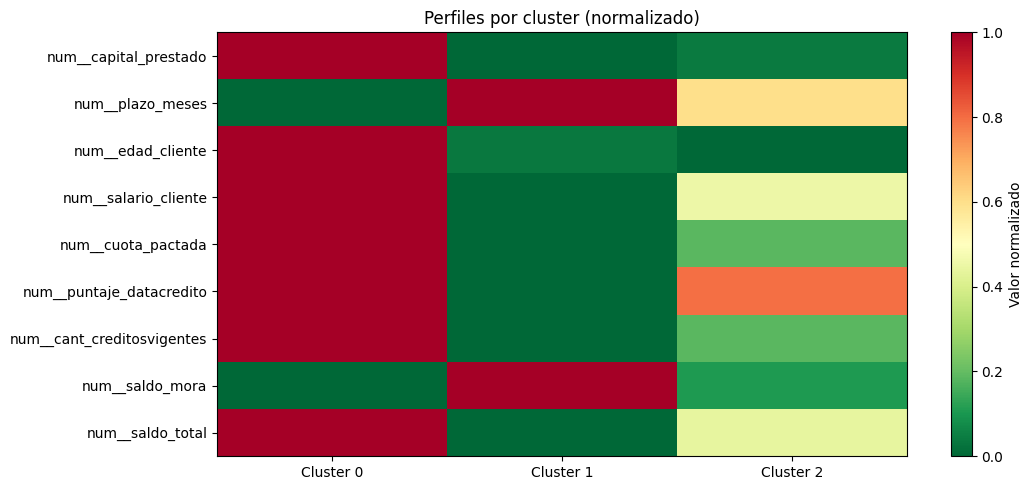

In [25]:
profiles_norm = profiles[profile_vars].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else x
)

plt.figure(figsize=(11, 5))
sns_heatmap_data = profiles_norm.T
plt.imshow(sns_heatmap_data, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(label="Valor normalizado")
plt.yticks(range(len(profile_vars)), profile_vars)
plt.xticks(range(k_final), [f"Cluster {i}" for i in profiles.index])
plt.title("Perfiles por cluster (normalizado)")
plt.tight_layout()
plt.show()

## Feature derivada: riesgo de cluster para los modelos supervisados
Se ordenan los clusters por tasa de incumplimiento; esta columna podría agregarse como feature adicional en `ft_engineering.py` si mejora el desempeño de los modelos de arriba.

In [26]:
cluster_risk = df_train_feat.groupby("cluster")["Pago_atiempo"].mean().sort_values()
risk_rank = {c: i for i, c in enumerate(cluster_risk.index)}

print("Orden de clusters por riesgo de incumplimiento (0=mayor riesgo):")
for c, tasa in cluster_risk.items():
    print(f"   Cluster {c}: {(1 - tasa) * 100:.1f}% incumplimiento -> risk_rank={risk_rank[c]}")

Orden de clusters por riesgo de incumplimiento (0=mayor riesgo):
   Cluster 0: 5.4% incumplimiento -> risk_rank=0
   Cluster 1: 5.3% incumplimiento -> risk_rank=1
   Cluster 2: 4.1% incumplimiento -> risk_rank=2
